<a href="https://colab.research.google.com/github/aa4758/ML_DL_study/blob/master/Self%20Study%20ML%20%2B%20DL/Principle_Component_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# attribution of data is called feature and 100 * 100 pixels image has 1000 features.
# these features are called dimension from machine learning and if we reduce these dimensions, then we can save a storage a lot
# dimension resuction algorithm ==> reduce data size and increase unsupervised learning model performance
# Also it's able to restore from reduced dimension to original dimention with at least loss
# PCA (principle Component Analysis): popular dimension reduction algorithm

In [ ]:
# variance: best vector to express data in direction, similar with linear regression
# the point is to find out a direction of the data
# principle component: the vector
# principle component is a direction from original data so number of component of principle component is same with number of features in original data set
# but it is able to reduce dimensions as moving original data set onto principle component orthogonality
# principle component data represents original data features in best ways

In [ ]:
# bigger variance, easier to distribute data ===> PCA is looking for the vector with biggest variance
# then principle component becomes best direction (features) to explain data distribution
# even we reduce dimensions, it's still exist the correlation of each data and core information (feature) of data though
# now the direction of principle component has longest distance between each data ==> large correlation
# orthogonal of the principle component is second longest discance btw data

In [ ]:
!wget https://bit.ly/fruits_300 -O fruits_300.npy
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

--2026-02-05 10:05:23--  https://bit.ly/fruits_300
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hongong-ml/raw/master/fruits_300.npy [following]
--2026-02-05 10:05:24--  https://github.com/rickiepark/hongong-ml/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hongong-ml/master/fruits_300.npy [following]
--2026-02-05 10:05:24--  https://raw.githubusercontent.com/rickiepark/hongong-ml/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443..

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50)                        # `n_components`: hyperparameter for number of principle components ==> easily just number of features to express data
pca.fit(fruits_2d)                                # it does not need target since it is a unsupervised training like K-Mean

PCA(n_components=50)

In [ ]:
print(pca.components_.shape)                      # 50 components since hyperparameter of n_components is 50

(50, 10000)


In [ ]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
  n = len(arr)
  row = int(np.ceil(n/10))
  col = n if row < 2 else 10

  fig, axs = plt.subplots(row, col, figsize=(col*ratio, row*ratio), squeeze=False)

  for i in range(row):
    for j in range(col):
      axs[i, j].imshow(arr[10*i+j], cmap='gray_r')
    axs[i, j].axis('off')
  plt.show()

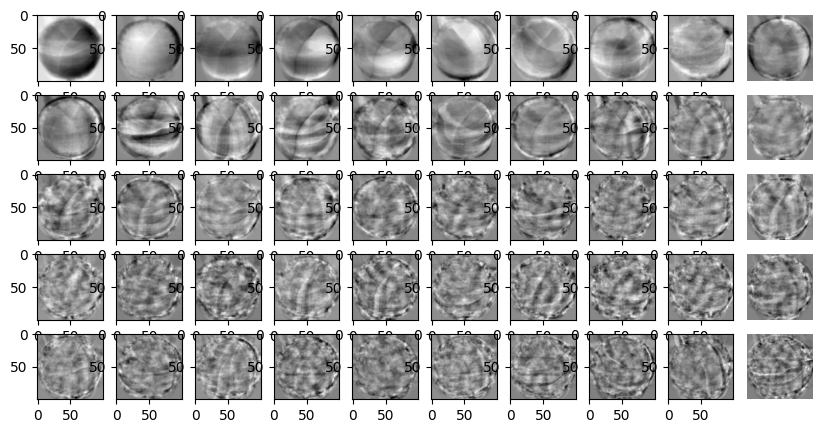

In [ ]:
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [ ]:
print(fruits_2d.shape)

(300, 10000)


In [ ]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)                                   # features are reduced from 10000 to 50 since hyperparameter of n_components is 50. it reduced to 50 features

(300, 50)


In [ ]:
fruits_inverse = pca.inverse_transform(fruits_pca)        # restore deleted data
print(fruits_inverse.shape)

(300, 10000)


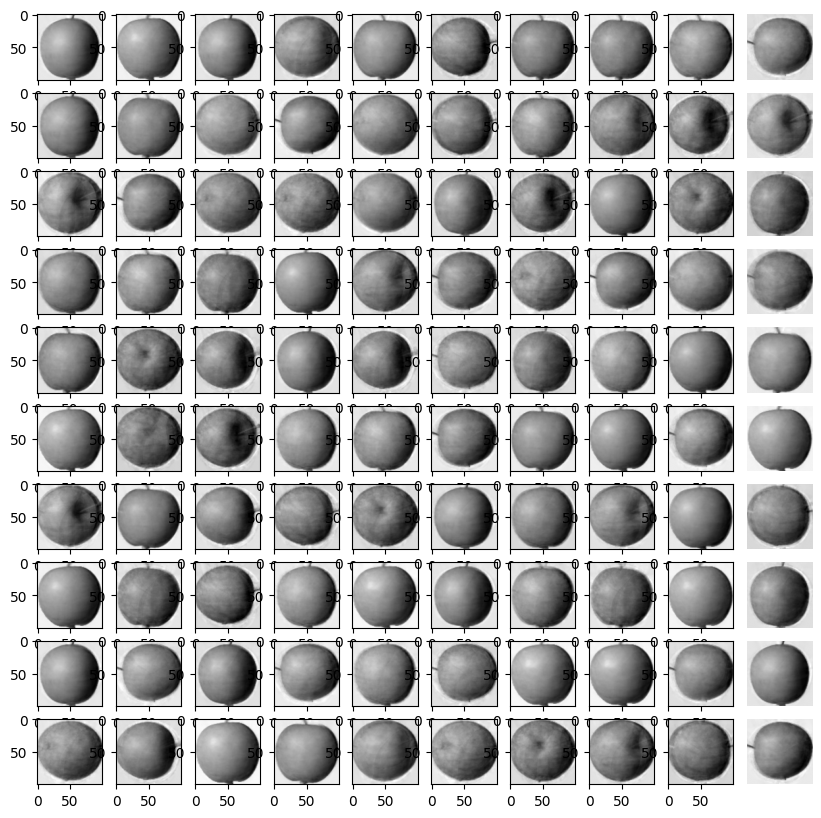

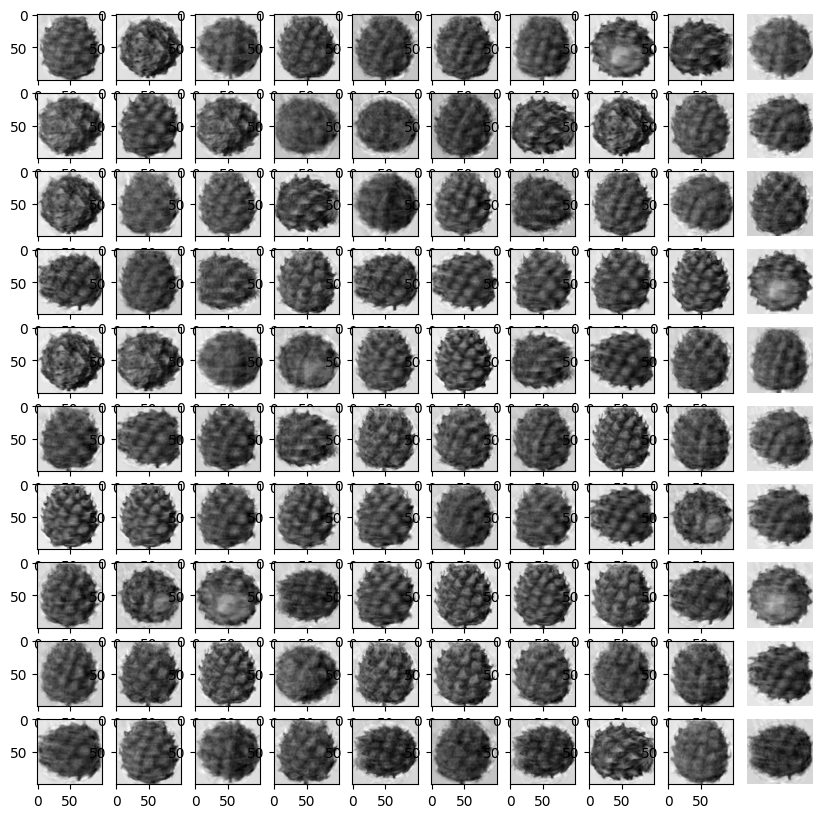

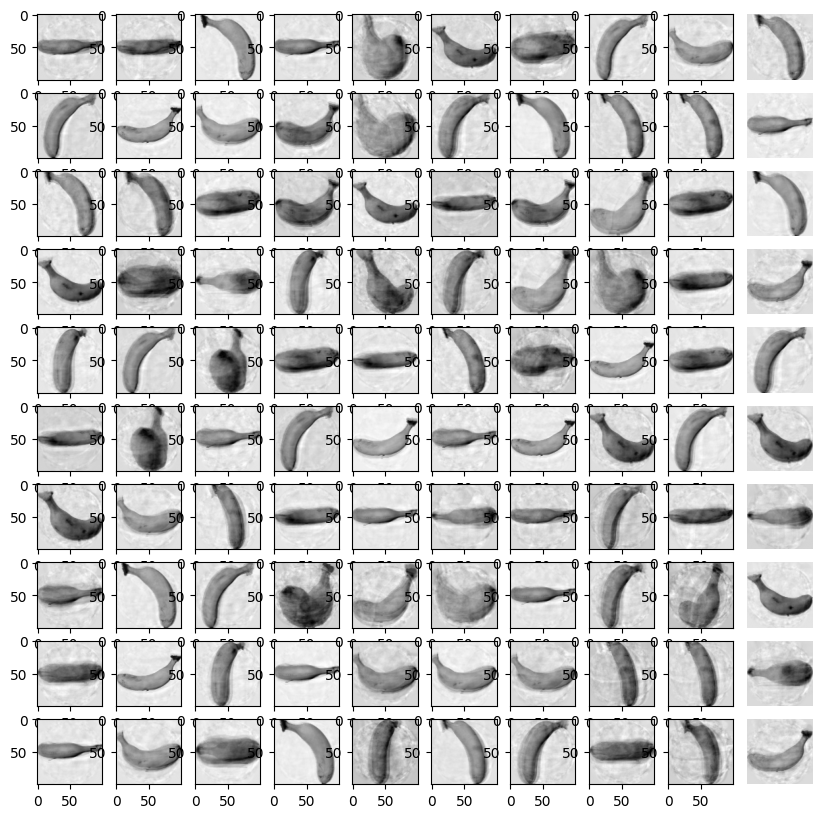

In [ ]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print("\n")                                                             # most of fruits are regenerated well since 50 features makes to transform with best saved variance

In [ ]:
# explained variance: score of how principle component represents variance of original data
# first principle component has biggest explained variance and sum of explained variance of all principle component is a ratio of accuracy

In [ ]:
print(np.sum(pca.explained_variance_ratio_))                    # 92% of variance are maintained after transform

0.9214726348111311


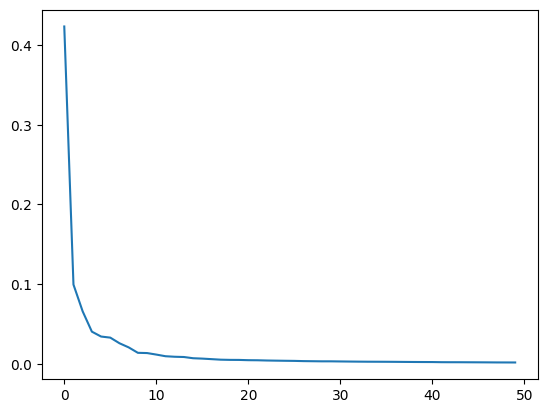

In [ ]:
plt.plot(pca.explained_variance_ratio_)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100000)

In [ ]:
target = np.array([0]*100 + [1]*100 + [2]*100)

In [ ]:
from sklearn.model_selection import cross_validate
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
1.044216012954712


In [ ]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.03292703628540039


In [ ]:
# fit_time with pca is much faster

In [ ]:
pca = PCA(n_components=0.5)                       # find out 0.5 of variance
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [ ]:
print(pca.n_components_)                          # only 2 features are able to express 50% of variance of original data

2


In [ ]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [ ]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.032458925247192384


In [ ]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters =3, random_state = 42)
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


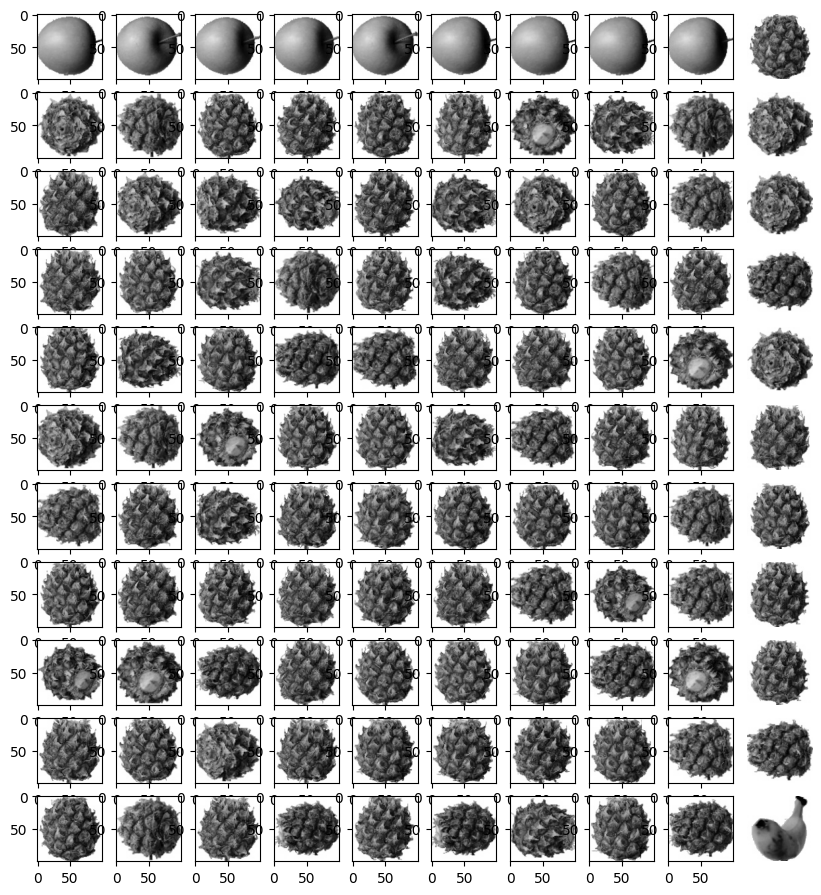

IndexError: index 99 is out of bounds for axis 0 with size 99

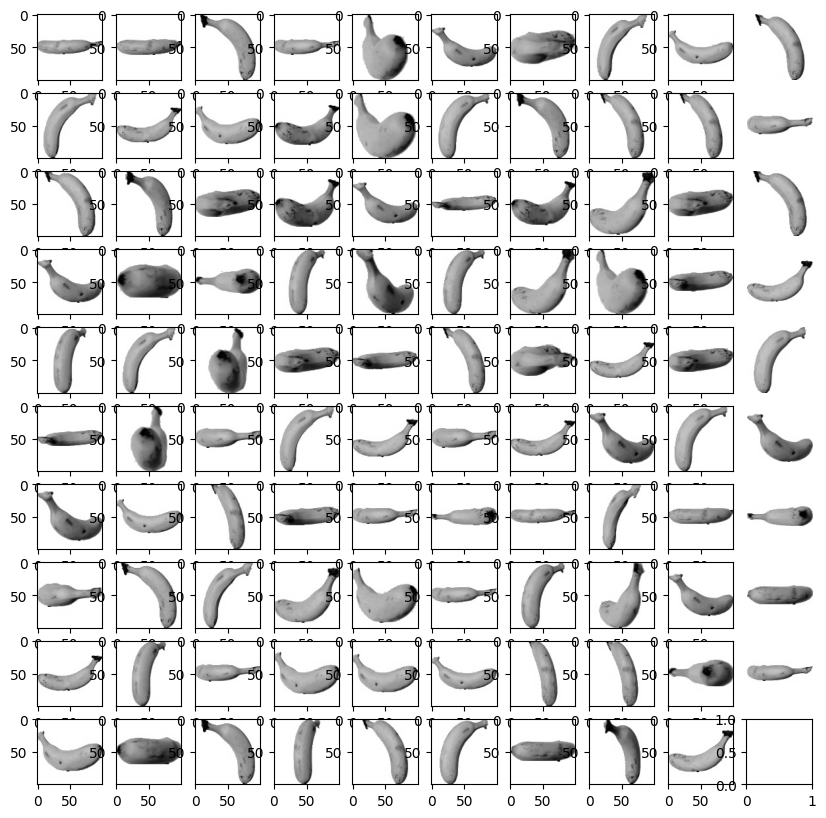

In [ ]:
for label in range(0, 3):
  draw_fruits(fruits[km.labels_ == label])
  print('\n')

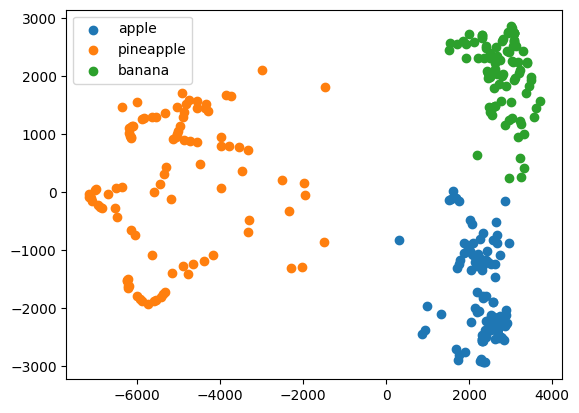

In [ ]:
for label in range(0, 3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:, 0], data[:, 1])
plt.legend(['apple', 'pineapple', 'banana'])
plt.show()